# 🌾 Seeds dataset — Шаг 1: Разведка данных (EDA)


В этом шаге отвечаем на вопросы:
1. Сколько объектов и признаков?
2. Какие у признаков масштабы?
3. Есть ли пропуски и дубликаты?
4. Как выглядят распределения и выбросы?
5. Как признаки связаны между собой (корреляции)?
6. Приводим всё к одному масштабу (**StandardScaler**).
7. Фиксируем **одну находку, которая удивила**.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Загрузка и первый взгляд

Файл `seeds_dataset.txt` — числа через пробелы, **без заголовка**. Поэтому задаём имена столбцов вручную
(7 геометрических признаков + закодированный сорт).

In [4]:
columns = [
    "area",            # площадь
    "perimeter",       # периметр
    "compactness",     # компактность
    "kernel_length",   # длина зерна
    "kernel_width",    # ширина зерна
    "asymmetry",       # коэффициент асимметрии
    "groove_length",   # длина бороздки
    "variety",         # сорт (1=Kama, 2=Rosa, 3=Canadian) — ПРЯЧЕМ его
]

df = pd.read_csv("seeds_dataset.txt", sep=r"\s+", names=columns)

# Признаки, с которыми работаем (сорт откладываем в сторону)
features = columns[:-1]
X = df[features]          # только геометрия
y = df["variety"]         # спрятанная правда, достанем только для проверки в конце

df.head()

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,variety
0,15.260,14.840,0.871,5.763,3.312,2.221,5.220,1
1,14.880,14.570,0.881,5.554,3.333,1.018,4.956,1
2,14.290,14.090,0.905,5.291,3.337,2.699,4.825,1
3,13.840,13.940,0.895,5.324,3.379,2.259,4.805,1
4,16.140,14.990,0.903,5.658,3.562,1.355,5.175,1


## 2. Размер, типы и базовая статистика

Сколько объектов и признаков, что за типы данных, и какие диапазоны значений.

In [5]:
print(f"Объектов (зёрен):   {df.shape[0]}")
print(f"Столбцов всего:      {df.shape[1]}  (7 признаков + 1 спрятанный сорт)")
print(f"Сортов в данных:     {y.nunique()}  ->  {sorted(y.unique())}")
print(f"Зёрен каждого сорта: {y.value_counts().sort_index().tolist()}  (идеально сбалансировано)")
print("\nТипы данных:")
print(df.dtypes)

Объектов (зёрен):   210
Столбцов всего:      8  (7 признаков + 1 спрятанный сорт)
Сортов в данных:     3  ->  [np.int64(1), np.int64(2), np.int64(3)]
Зёрен каждого сорта: [70, 70, 70]  (идеально сбалансировано)

Типы данных:
area             float64
perimeter        float64
compactness      float64
kernel_length    float64
kernel_width     float64
asymmetry        float64
groove_length    float64
variety            int64
dtype: object


In [6]:
# Полная описательная статистика по признакам
X.describe().T

,count,mean,std,min,25%,50%,75%,max
area,210.000,14.848,2.910,10.590,12.270,14.355,17.305,21.180
perimeter,210.000,14.559,1.306,12.410,13.450,14.320,15.715,17.250
compactness,210.000,0.871,0.024,0.808,0.857,0.873,0.888,0.918
kernel_length,210.000,5.629,0.443,4.899,5.262,5.524,5.980,6.675
kernel_width,210.000,3.259,0.378,2.630,2.944,3.237,3.562,4.033
asymmetry,210.000,3.700,1.504,0.765,2.562,3.599,4.769,8.456
groove_length,210.000,5.408,0.491,4.519,5.045,5.223,5.877,6.550


## 3. Пропуски и дубликаты

Прежде чем строить что-либо — убеждаемся, что данные чистые.

In [7]:
print("Пропусков по столбцам:")
print(df.isnull().sum())
print(f"\nВсего пропусков:  {df.isnull().sum().sum()}")
print(f"Дубликатов строк: {df.duplicated().sum()}")

Пропусков по столбцам:
area             0
perimeter        0
compactness      0
kernel_length    0
kernel_width     0
asymmetry        0
groove_length    0
variety          0
dtype: int64

Всего пропусков:  0
Дубликатов строк: 0


## 4. Масштабы признаков — почему без StandardScaler нельзя

Сравним разброс (std) и отношение max/min у признаков. Если масштабы сильно разные,
то и кластеризация (по расстояниям), и PCA (по дисперсии) будут смотреть в основном
на признак с самыми большими числами, а остальные «не услышат».

In [8]:
scale_check = pd.DataFrame({
    "min":      X.min(),
    "max":      X.max(),
    "std":      X.std(),
    "max/min":  (X.max() / X.min()),
}).sort_values("std", ascending=False)

print("Разброс признаков в ИСХОДНЫХ единицах:")
display(scale_check.round(3))

ratio = X.std().max() / X.std().min()
print(f"std самого 'большого' признака больше самого 'маленького' в {ratio:.0f} раз.")
print("=> без масштабирования area задавит compactness. Нужен StandardScaler.")

Разброс признаков в ИСХОДНЫХ единицах:


,min,max,std,max/min
area,10.590,21.180,2.910,2.000
asymmetry,0.765,8.456,1.504,11.052
perimeter,12.410,17.250,1.306,1.390
groove_length,4.519,6.550,0.491,1.449
kernel_length,4.899,6.675,0.443,1.363
kernel_width,2.630,4.033,0.378,1.533
compactness,0.808,0.918,0.024,1.136


std самого 'большого' признака больше самого 'маленького' в 123 раз.
=> без масштабирования area задавит compactness. Нужен StandardScaler.


## 5. Распределения признаков

Гистограммы: смотрим форму (одногорбая / двугорбая), скошенность, подозрительные хвосты.

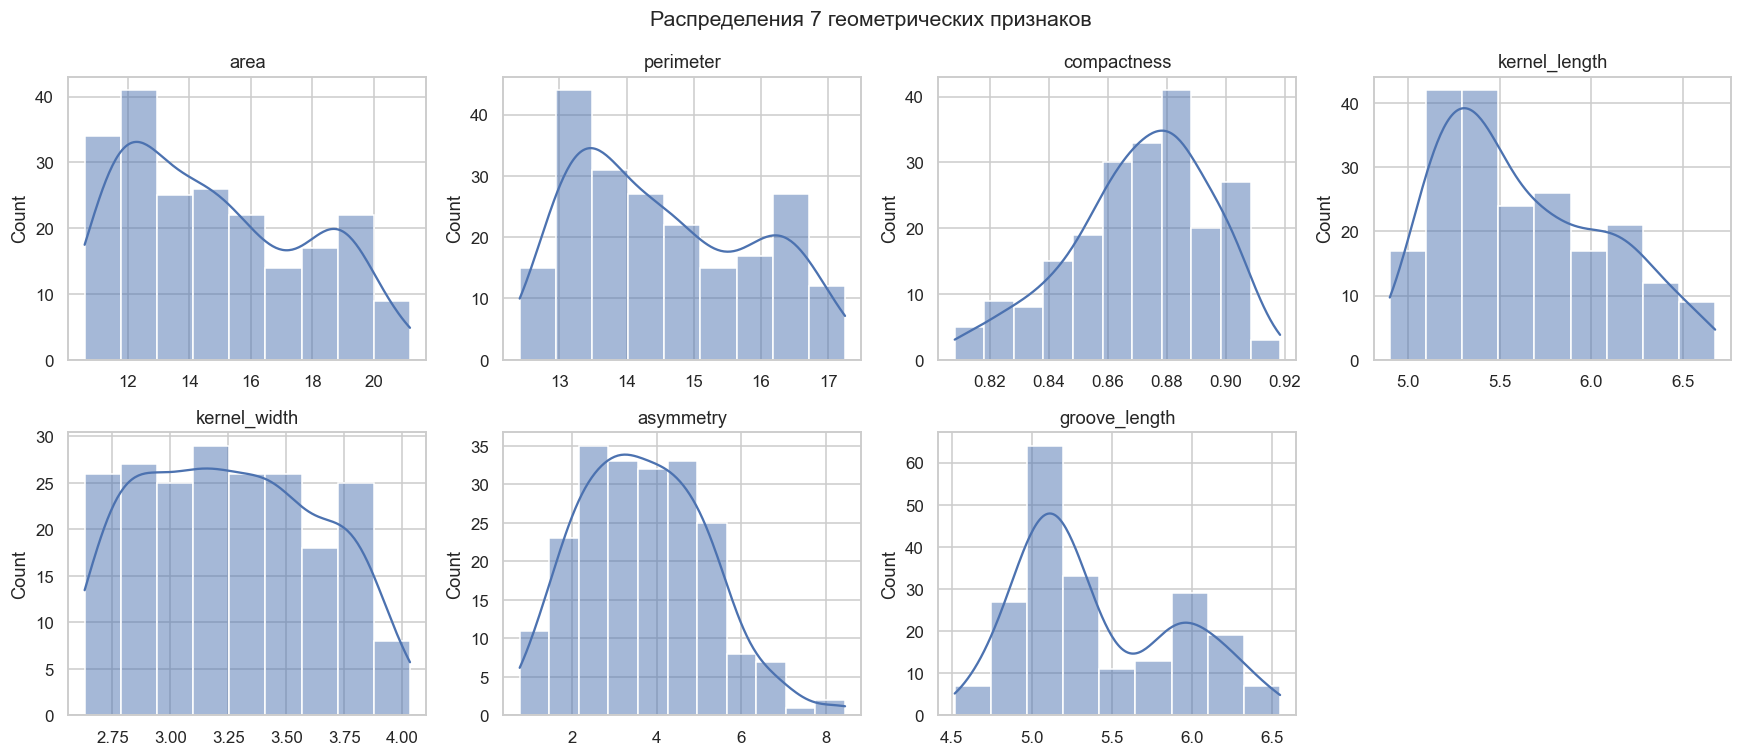

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(X[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
axes.flat[-1].axis("off")  # 8-я клетка пустая (признаков 7)
fig.suptitle("Распределения 7 геометрических признаков", fontsize=14)
fig.tight_layout()
plt.show()

## 6. Выбросы

Boxplot по каждому признаку. Точки за «усами» — кандидаты в выбросы.
Чтобы признаки можно было сравнить на одной картинке, рисуем их в **стандартизованном** виде.

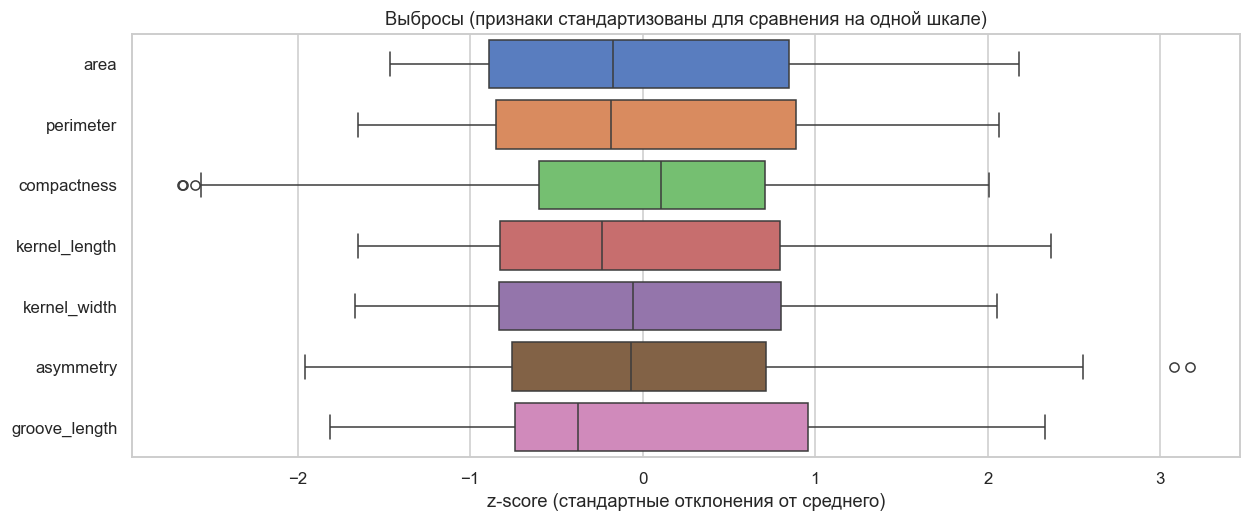

Число выбросов по правилу 1.5*IQR:
area             0
perimeter        0
compactness      3
kernel_length    0
kernel_width     0
asymmetry        2
groove_length    0
dtype: int64


In [8]:
X_std_preview = pd.DataFrame(
    StandardScaler().fit_transform(X), columns=features
)

plt.figure(figsize=(13, 5))
sns.boxplot(data=X_std_preview, orient="h", palette="muted")
plt.title("Выбросы (признаки стандартизованы для сравнения на одной шкале)")
plt.xlabel("z-score (стандартные отклонения от среднего)")
plt.show()

# Сколько точек выходит за 1.5*IQR по каждому признаку
Q1, Q3 = X.quantile(0.25), X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < Q1 - 1.5 * IQR) | (X > Q3 + 1.5 * IQR)).sum()
print("Число выбросов по правилу 1.5*IQR:")
print(outliers)

## 7. Матрица корреляций

Смотрим, какие признаки дублируют друг друга. Сильная корреляция = признаки несут
почти одну и ту же информацию (важно для PCA на следующем шаге).
Сорт `variety` в матрицу **не берём** — он спрятан.

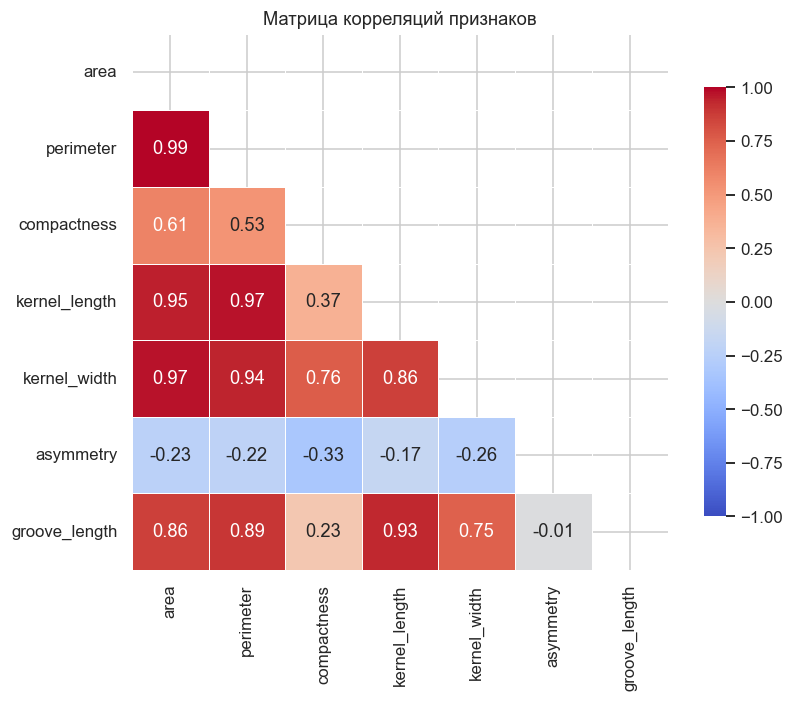

In [9]:
corr = X.corr()

plt.figure(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

## 8. Приведение к одному масштабу — StandardScaler

`StandardScaler` для каждого признака вычитает среднее и делит на std.
После этого у каждого признака **среднее ≈ 0** и **std ≈ 1** — все «весят» одинаково.
Именно `X_scaled` пойдёт дальше в кластеризацию и PCA.

После StandardScaler (проверка):


,mean,std
area,-0.000,1.002
perimeter,0.000,1.002
compactness,0.000,1.002
kernel_length,-0.000,1.002
kernel_width,-0.000,1.002
asymmetry,-0.000,1.002
groove_length,-0.000,1.002


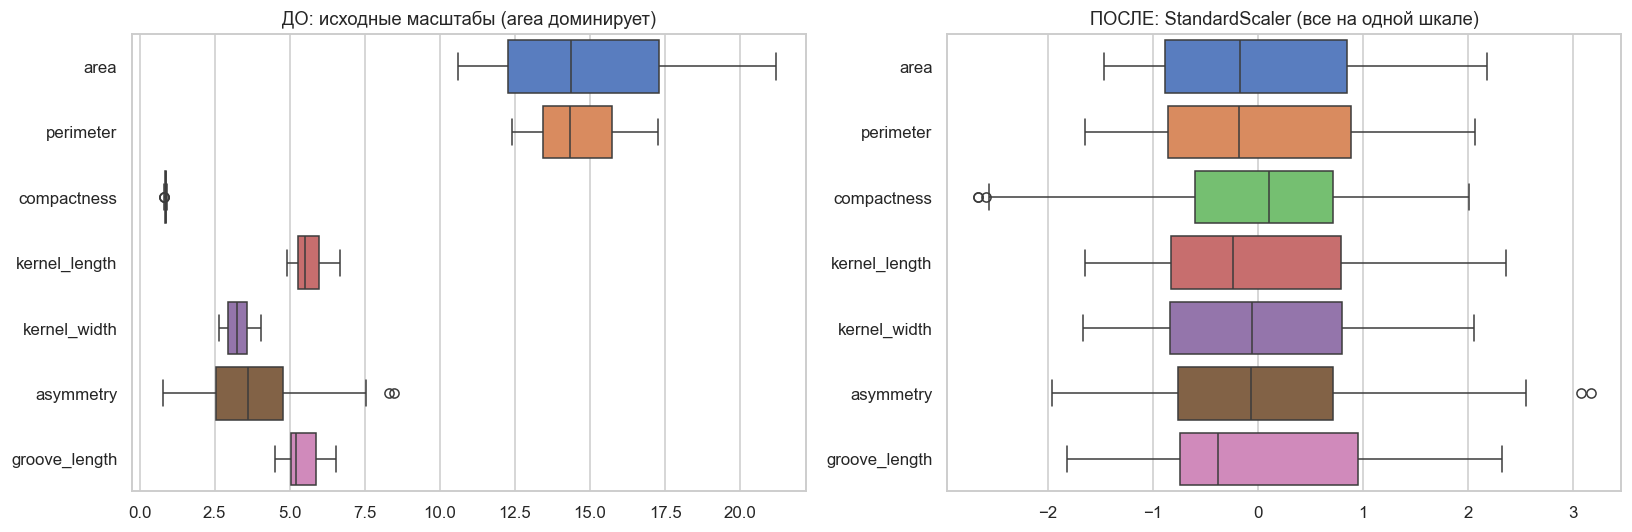

In [10]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

print("После StandardScaler (проверка):")
check = pd.DataFrame({"mean": X_scaled.mean(), "std": X_scaled.std()})
display(check.round(3))

# До / после на одной картинке
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=X, orient="h", ax=a1, palette="muted")
a1.set_title("ДО: исходные масштабы (area доминирует)")
sns.boxplot(data=X_scaled, orient="h", ax=a2, palette="muted")
a2.set_title("ПОСЛЕ: StandardScaler (все на одной шкале)")
fig.tight_layout()
plt.show()

## 💡 Находка, которая удивила (для выступления)

**`area` и `perimeter` коррелируют на 0.994 — это практически один и тот же признак.**

И это не единичный случай: пять «размерных» признаков (area, perimeter, kernel_length,
kernel_width, groove_length) сцеплены между собой на 0.9+. То есть **формально признаков 7,
а независимой информации — примерно 2–3 «оси»**: общий размер зерна и его форма/асимметрия.

Почему это удивляет и зачем это на выступлении:
- кажется, что 7 признаков = 7 разных взглядов на зерно, а на деле половина дублирует друг друга;
- это прямое оправдание следующего шага — **PCA** сожмёт 7 признаков в 2–3 без потери смысла;
- бонус-наблюдение: самый «грязный» признак `asymmetry` (разброс значений в 11 раз, больше всего
  выбросов) — единственный, кто почти не связан с размером, и поэтому он несёт **уникальную**
  информацию о сорте.

Ниже — доказательство числами.

In [11]:
# Доказательство находки
pair = X.corr().loc["area", "perimeter"]
print(f"corr(area, perimeter) = {pair:.3f}\n")

print("Топ-5 самых сильных связей между признаками:")
c = X.corr().abs()
c.values[np.triu_indices_from(c, 0)] = 0
top = c.stack().sort_values(ascending=False).head(5)
for (f1, f2), v in top.items():
    print(f"  {f1:14s} ~ {f2:14s} : {v:.3f}")

print("\nasymmetry — связь с размерными признаками (почти нулевая = уникален):")
print(X.corr()["asymmetry"].drop("asymmetry").round(3).sort_values())

corr(area, perimeter) = 0.994

Топ-5 самых сильных связей между признаками:
  perimeter      ~ area           : 0.994
  kernel_length  ~ perimeter      : 0.972
  kernel_width   ~ area           : 0.971
  kernel_length  ~ area           : 0.950
  kernel_width   ~ perimeter      : 0.945

asymmetry — связь с размерными признаками (почти нулевая = уникален):
compactness     -0.331
kernel_width    -0.258
area            -0.230
perimeter       -0.217
kernel_length   -0.172
groove_length   -0.011
Name: asymmetry, dtype: float64


---
# 🔍 Шаг 2: Кластеризация (KMeans) — ищем структуру без меток

Меток у нас «нет» (`variety` спрятан). Поэтому группы ищем сами с помощью **KMeans**
на **масштабированных** данных `X_scaled`.

Число кластеров `k` **не угадываем**, а выбираем по двум инструментам:
- **метод локтя** — как падает `inertia` (сумма квадратов расстояний до центров) с ростом `k`;
- **коэффициент силуэта** — насколько объекты хорошо лежат в своём кластере (от −1 до 1, больше — лучше).

И, по принципу «не верь — проверь», смотрим не одно `k`, а **соседние значения** k = 2…8.

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 9)
rows = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
    })

scores = pd.DataFrame(rows).set_index("k")
# на сколько падает inertia при добавлении кластера
scores["inertia_drop"] = -scores["inertia"].diff()
scores.round(3)

,inertia,silhouette,inertia_drop
k,,,
2,659.172,0.466,NaN
3,430.659,0.401,228.513
4,371.302,0.328,59.357
5,326.514,0.285,44.788
6,289.804,0.280,36.710
7,262.974,0.271,26.830
8,240.643,0.251,22.331


## Метод локтя + силуэт на одной картинке

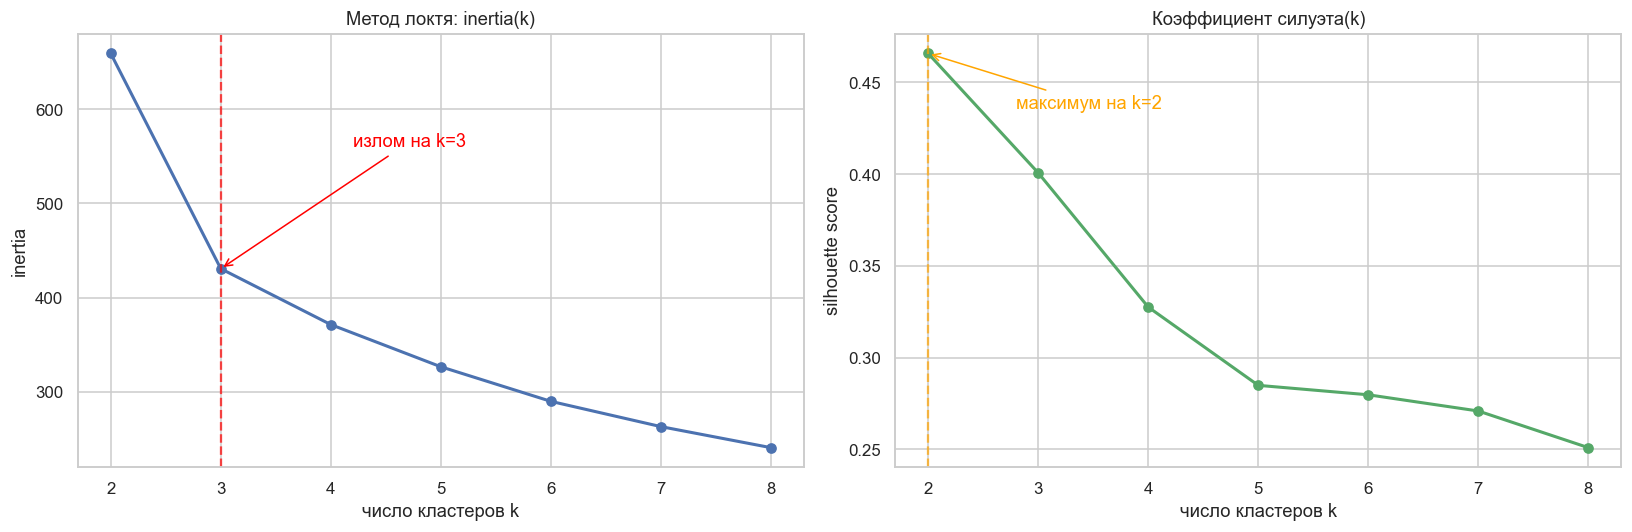

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Локоть ---
a1.plot(scores.index, scores["inertia"], "o-", color="#4C72B0", lw=2)
a1.set_title("Метод локтя: inertia(k)")
a1.set_xlabel("число кластеров k"); a1.set_ylabel("inertia")
a1.axvline(3, color="red", ls="--", alpha=.7)
a1.annotate("излом на k=3", xy=(3, scores.loc[3, "inertia"]),
            xytext=(4.2, 560), color="red",
            arrowprops=dict(arrowstyle="->", color="red"))

# --- Силуэт ---
a2.plot(scores.index, scores["silhouette"], "o-", color="#55A868", lw=2)
a2.set_title("Коэффициент силуэта(k)")
a2.set_xlabel("число кластеров k"); a2.set_ylabel("silhouette score")
best_sil = scores["silhouette"].idxmax()
a2.axvline(best_sil, color="orange", ls="--", alpha=.7)
a2.annotate(f"максимум на k={best_sil}", xy=(best_sil, scores["silhouette"].max()),
            xytext=(best_sil + .8, scores["silhouette"].max() - .03), color="orange",
            arrowprops=dict(arrowstyle="->", color="orange"))

fig.tight_layout(); plt.show()

## Выбор k — и почему метрики спорят

Смотрим на цифры внимательно:

| k | inertia | падение inertia | silhouette |
|---|---------|-----------------|------------|
| 2 | 659 | — | **0.466** ← максимум |
| 3 | 431 | **−228** (резко) | 0.401 |
| 4 | 371 | −59 (слабо) | 0.328 |
| 5 | 327 | −45 | 0.285 |

**Локоть однозначно указывает на k=3:** при переходе 2→3 inertia падает на 228, а дальше (3→4)
всего на 59 — кривая «ломается» ровно на тройке. Добавлять кластеры после 3 почти не уменьшает ошибку.

**Силуэт формально выше на k=2 (0.466 против 0.401).** Это не ошибка: два сорта геометрически
похожи, и силуэту «удобнее» слить их в один шар — тогда границы чище. Но k=3 идёт **близким вторым**,
разрыв небольшой.

**Решение: k = 3.** Аргументы:
1. локоть резкий и недвусмысленный именно на 3;
2. проигрыш силуэта на 2→3 крошечный (0.07), а выигрыш в осмысленности структуры большой;
3. соседние k=4,5 хуже по обеим метрикам сразу — их отбрасываем уверенно.

Мы проверили соседние значения и не поверили первому `k` на слово — k=2 «побеждал» только по
силуэту, но проигрывал по локтю и по смыслу.

In [14]:
K = 3
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Выбрано кластеров: k = {K}")
print(f"Силуэт при k={K}: {silhouette_score(X_scaled, df['cluster']):.3f}")
print("\nРазмеры кластеров:")
print(df["cluster"].value_counts().sort_index())

Выбрано кластеров: k = 3
Силуэт при k=3: 0.401

Размеры кластеров:
cluster
0    72
1    67
2    71
Name: count, dtype: int64


## Как выглядят кластеры (взгляд через PCA)

Сжимаем 7 признаков в 2 главные компоненты только для **визуализации** и красим точки
по найденному кластеру. Это ещё не проверка против настоящего сорта — её сделаем на следующем шаге.

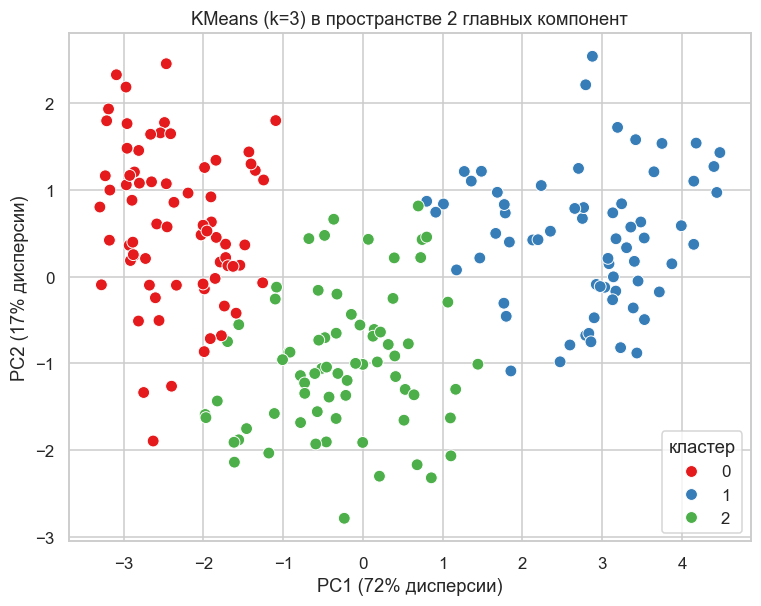

Две компоненты объясняют 89% дисперсии.


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df["pc1"], df["pc2"] = pcs[:, 0], pcs[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="cluster",
                palette="Set1", s=60, edgecolor="white")
plt.title(f"KMeans (k={K}) в пространстве 2 главных компонент")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% дисперсии)")
plt.legend(title="кластер")
plt.show()

print(f"Две компоненты объясняют {pca.explained_variance_ratio_[:2].sum()*100:.0f}% дисперсии.")

## Промежуточный честный вывод

- KMeans на масштабированных данных дал **3 кластера** примерно равного размера (~70 объектов) —
  и это согласуется с локтём.
- На картинке PCA один кластер отделён чётко, а два других **частично перекрываются** — ровно поэтому
  силуэт колебался между k=2 и k=3.
- Метки мы пока не подсматривали. На следующем шаге превратим кластеры в метку и проверим,
  совпадают ли они с настоящими сортами (и оценим те самые «перепутанные» зёрна).

---
# 🏷️ Шаг 3: Превращаем кластеры в осмысленную метку

Номера кластеров, которые выдал KMeans (`cluster` = 0/1/2), — **это и есть наша новая метка**.
Её не было в исходных данных: мы её **сконструировали сами**. С этого момента у нас появилась цель,
которую можно будет предсказывать на следующем шаге.

Но «кластер 0 / 1 / 2» ничего не объясняет. Дадим группам **человеческие имена по их средним
признакам** — так, чтобы имя сразу говорило, чем группа отличается от других.

## 3.1 Профиль кластеров — средние признаки

Смотрим средние двумя способами:
- в **исходных единицах** (мм², мм и т.д.) — для интуиции;
- в **z-score** (на сколько std кластер выше/ниже общего среднего) — чтобы честно сравнивать
  признаки в разных шкалах. Здесь **+** значит «выше среднего по всем зёрнам», **−** «ниже».

In [16]:
# Средние в исходных единицах
profile_raw = df.groupby("cluster")[features].mean()
print("Средние признаки по кластерам (исходные единицы):")
display(profile_raw.round(2))

# Средние в z-score (относительно общего среднего)
profile_z = (pd.DataFrame(X_scaled, columns=features)
             .assign(cluster=df["cluster"])
             .groupby("cluster").mean())
print("\nТе же средние в z-score (+ выше общего среднего, - ниже):")
display(profile_z.round(2))

Средние признаки по кластерам (исходные единицы):


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
cluster,,,,,,,
0,11.860,13.250,0.850,5.230,2.850,4.740,5.100
1,18.500,16.200,0.880,6.180,3.700,3.630,6.040
2,14.440,14.340,0.880,5.510,3.260,2.710,5.120



Те же средние в z-score (+ выше общего среднего, - ниже):


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
cluster,,,,,,,
0,-1.030,-1.010,-0.960,-0.900,-1.090,0.690,-0.620
1,1.260,1.260,0.560,1.240,1.160,-0.050,1.290
2,-0.140,-0.170,0.450,-0.260,0.000,-0.660,-0.590


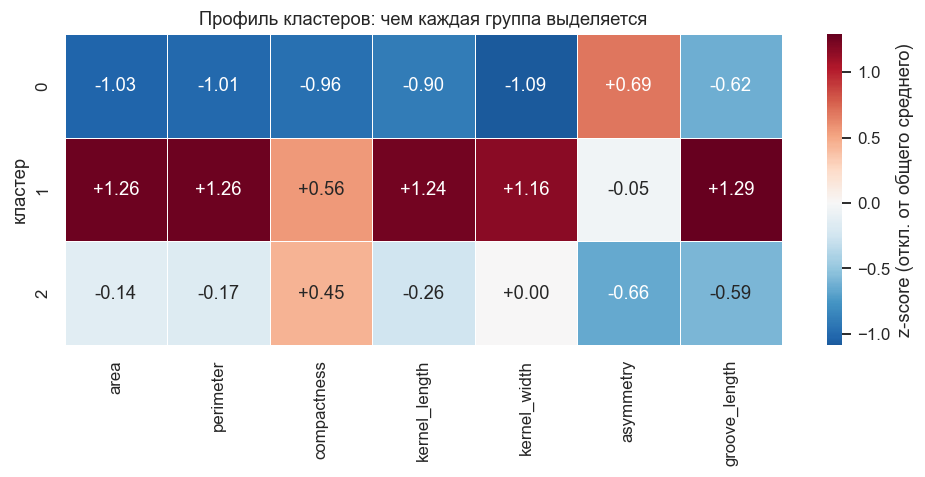

In [17]:
# Тепловая карта профилей — наглядно видно, чем кластеры отличаются
plt.figure(figsize=(9, 4.5))
sns.heatmap(profile_z, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            linewidths=.5, cbar_kws={"label": "z-score (откл. от общего среднего)"})
plt.title("Профиль кластеров: чем каждая группа выделяется")
plt.ylabel("кластер"); plt.xlabel("")
plt.tight_layout(); plt.show()

## 3.2 Читаем профили и даём имена

Разбираем каждый кластер по таблице z-score (`+` выше среднего, `−` ниже):

**Кластер 0 — «Мелкие кривые зёрна»** (72 шт.)
- размер по всем осям сильно ниже среднего (area −1.03, ширина −1.09, длина −0.90) — **самые мелкие**;
- compactness −0.96 — **самые некомпактные** (вытянутые, неровные);
- asymmetry **+0.69** — **самые перекошенные** из трёх групп.
- Короче: маленькие и кривоватые.

**Кластер 1 — «Крупные ровные зёрна»** (67 шт.)
- **всё** выше среднего: area +1.26, периметр +1.26, длина +1.24, ширина +1.16, бороздка +1.29 — **самые крупные**;
- asymmetry ≈ 0 — асимметрия средняя.
- Короче: большие, длинные, полнотелые.

**Кластер 2 — «Средние округлые симметричные»** (71 шт.)
- размер около среднего (area −0.14) — **средние**;
- compactness +0.45 — относительно **округлые/компактные**;
- asymmetry **−0.66** — **самые симметричные** (ровные).
- Короче: средние по размеру, но самые «правильной» формы.

Имена выбраны так, чтобы каждое объясняло **отличие от остальных**:
размер (мелкий/крупный/средний) + ключевая особенность формы (кривые/полнотелые/симметричные).

In [18]:
# Закрепляем имена как новую метку
cluster_names = {
    0: "Мелкие кривые",
    1: "Крупные ровные",
    2: "Средние симметричные",
}

df["segment"] = df["cluster"].map(cluster_names)

print("Новая сконструированная метка 'segment':")
print(df["segment"].value_counts())
display(df[["area", "perimeter", "asymmetry", "cluster", "segment"]].head())

Новая сконструированная метка 'segment':
segment
Мелкие кривые           72
Средние симметричные    71
Крупные ровные          67
Name: count, dtype: int64


,area,perimeter,asymmetry,cluster,segment
0,15.260,14.840,2.221,2,Средние симметричные
1,14.880,14.570,1.018,2,Средние симметричные
2,14.290,14.090,2.699,2,Средние симметричные
3,13.840,13.940,2.259,2,Средние симметричные
4,16.140,14.990,1.355,2,Средние симметричные


## 3.3 Имена на картинке PCA

Та же визуализация, но теперь точки подписаны человеческими именами, а не номерами.

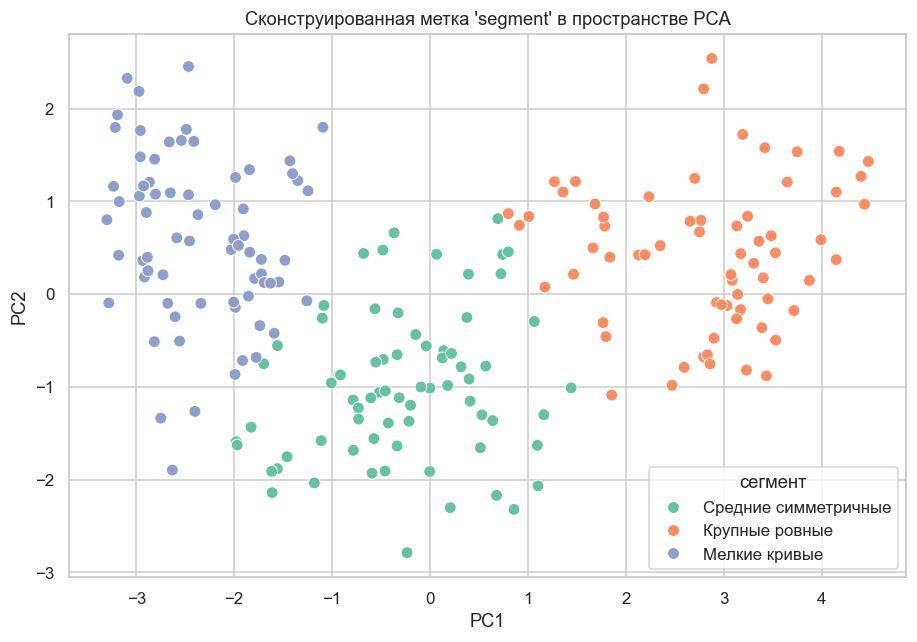

In [19]:
plt.figure(figsize=(8.5, 6))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="segment",
                palette="Set2", s=60, edgecolor="white")
plt.title("Сконструированная метка 'segment' в пространстве PCA")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="сегмент")
plt.tight_layout(); plt.show()

## Итог шага

- Номера кластеров KMeans стали столбцом `cluster`, а затем осмысленной меткой **`segment`**.
- Мы **сами создали цель**, которой в исходных данных не было: «Мелкие кривые», «Крупные ровные»,
  «Средние симметричные».
- Каждое имя выведено из средних признаков и объясняет, **чем группа отличается** от других,
  а не просто «кластер 0/1/2».
- На следующем шаге проверим: можно ли эту метку **предсказывать** (обучение с учителем),
  и совпадает ли она со спрятанным настоящим сортом.

---
# 🗺️ Шаг 4: PCA — сжимаем 7 признаков в 2 и смотрим на кластеры

Признаков 7 — глазом 7-мерное пространство не увидеть. **PCA (метод главных компонент)**
строит новые оси (компоненты) так, чтобы первая удерживала максимум разброса данных,
вторая — максимум из оставшегося, и т.д. Берём только **две** первые и рисуем зёрна на плоскости,
раскрасив по нашей метке `segment` из шага 3.

Ключевой честный вопрос: **какую долю дисперсии (разброса) удержали 2 компоненты?**
Если мало — двумерная картинка обманчива, и это тоже вывод.

## 4.1 Сколько информации удерживают компоненты

In [20]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_scaled)
evr = pca_full.explained_variance_ratio_

var_table = pd.DataFrame({
    "компонента": [f"PC{i+1}" for i in range(len(evr))],
    "доля дисперсии":      evr,
    "накопленная доля":    np.cumsum(evr),
}).set_index("компонента")
print("Доля удержанной дисперсии по компонентам:")
display(var_table.round(3))

kept = evr[:2].sum()
print(f"PC1 + PC2 удерживают {kept*100:.1f}% всей дисперсии.")

Доля удержанной дисперсии по компонентам:


,доля дисперсии,накопленная доля
компонента,,
PC1,0.719,0.719
PC2,0.171,0.890
PC3,0.097,0.987
PC4,0.010,0.996
PC5,0.003,0.999
PC6,0.001,1.000
PC7,0.000,1.000


PC1 + PC2 удерживают 89.0% всей дисперсии.


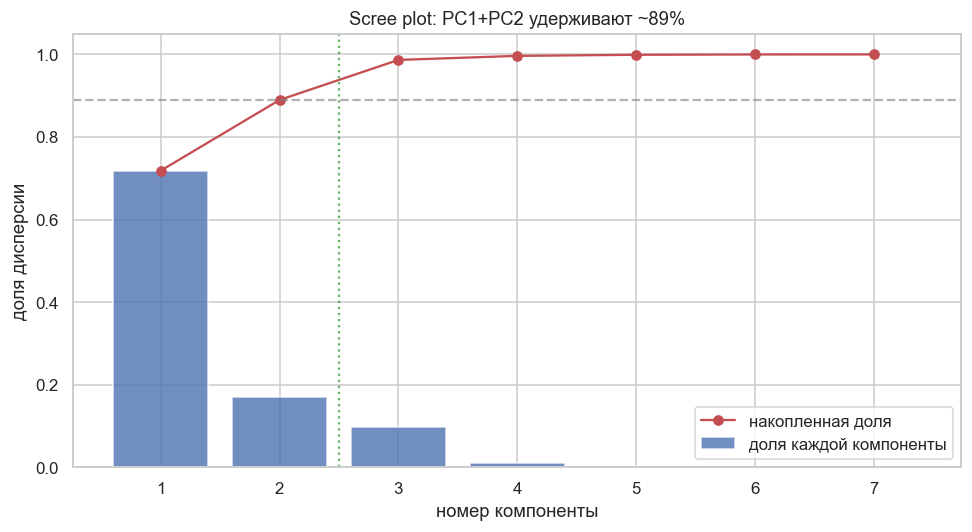

In [21]:
# Scree plot: вклад каждой компоненты + накопленная доля
fig, ax = plt.subplots(figsize=(9, 5))
xs = range(1, len(evr) + 1)
ax.bar(xs, evr, color="#4C72B0", alpha=.8, label="доля каждой компоненты")
ax.plot(xs, np.cumsum(evr), "o-", color="#C44E52", label="накопленная доля")
ax.axhline(0.89, color="gray", ls="--", alpha=.6)
ax.axvline(2.5, color="green", ls=":", alpha=.6)
ax.set_xlabel("номер компоненты"); ax.set_ylabel("доля дисперсии")
ax.set_title("Scree plot: PC1+PC2 удерживают ~89%")
ax.set_xticks(list(xs)); ax.legend()
plt.tight_layout(); plt.show()

## 4.2 Объекты на плоскости PC1–PC2, раскрашенные по метке

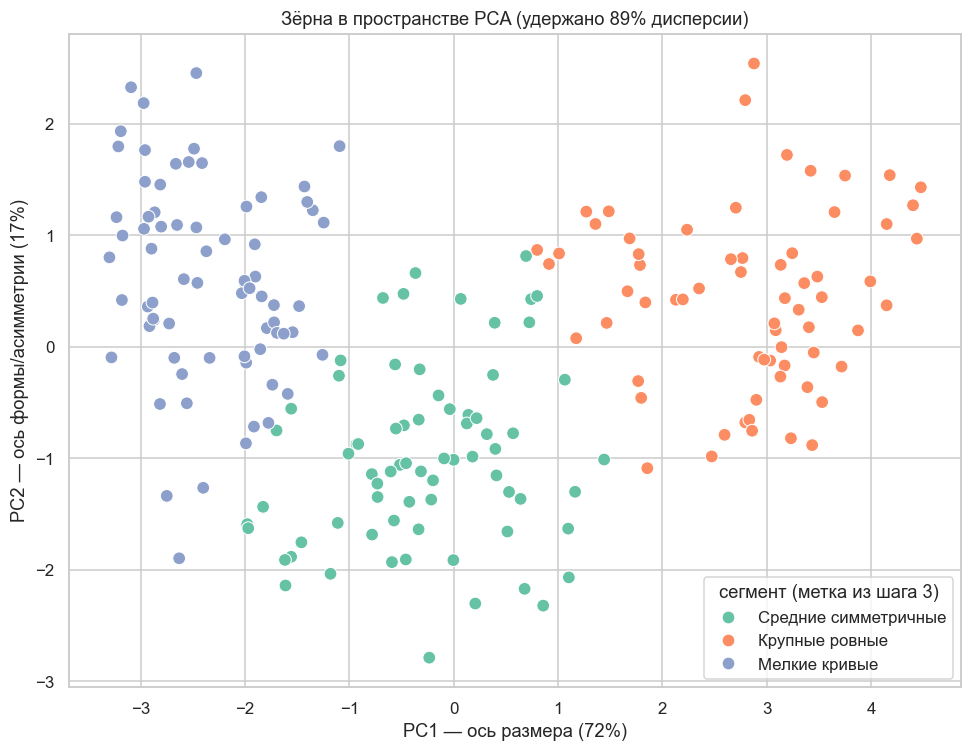

In [22]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["pc1"], df["pc2"] = coords[:, 0], coords[:, 1]
e1, e2 = pca.explained_variance_ratio_

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="segment",
                palette="Set2", s=70, edgecolor="white")
plt.title(f"Зёрна в пространстве PCA (удержано {(e1+e2)*100:.0f}% дисперсии)")
plt.xlabel(f"PC1 — ось размера ({e1*100:.0f}%)")
plt.ylabel(f"PC2 — ось формы/асимметрии ({e2*100:.0f}%)")
plt.legend(title="сегмент (метка из шага 3)")
plt.tight_layout(); plt.show()

## 4.3 Что означают сами оси PC1 и PC2 (загрузки)

Загрузка (`loading`) — вклад каждого исходного признака в компоненту. По ним видно, что
**ось PC1 — это «размер»**, а **ось PC2 — это «форма/асимметрия»**. Это прямо объясняет
нашу находку из EDA: 7 признаков фактически сворачиваются в 2 смысловые оси.

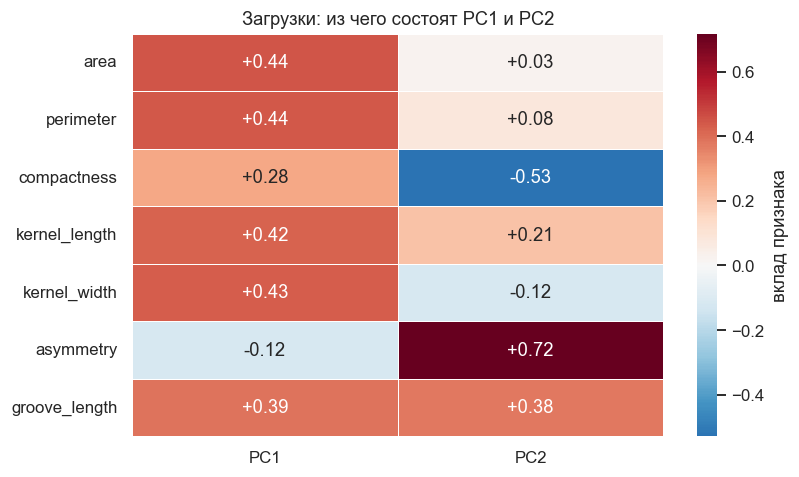

PC1: все размерные признаки (~+0.4) -> это 'общий размер зерна'.
PC2: asymmetry (+0.72) против compactness (-0.53) -> это 'форма/кривизна'.


In [23]:
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features)

plt.figure(figsize=(7.5, 4.5))
sns.heatmap(loadings, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            linewidths=.5, cbar_kws={"label": "вклад признака"})
plt.title("Загрузки: из чего состоят PC1 и PC2")
plt.tight_layout(); plt.show()

print("PC1: все размерные признаки (~+0.4) -> это 'общий размер зерна'.")
print("PC2: asymmetry (+0.72) против compactness (-0.53) -> это 'форма/кривизна'.")

## Вывод шага

- **Две компоненты удержали 89% дисперсии** (PC1 ≈ 72%, PC2 ≈ 17%). Это **много**, поэтому
  двумерная картинка **честная**: то, что мы видим на плоскости, действительно отражает структуру
  7-мерных данных, а не артефакт сжатия.
- **«Крупные ровные»** отделяются **чётко** — это плотный отдельный остров справа по оси размера.
- **«Мелкие кривые»** и **«Средние симметричные»** стоят рядом и **местами налезают** друг на друга:
  граница между ними размытая. Это ровно то перекрытие, из-за которого на шаге 2 спорили локоть (k=3)
  и силуэт (k=2).
- Смысл осей читается: горизонталь — размер зерна, вертикаль — асимметрия/форма. Значит группы
  различаются в первую очередь размером, а две похожие — тонкой разницей в форме.
- Честная оговорка: 11% дисперсии в картинку не попали, поэтому пара точек на границе
  может на самом деле лежать чуть иначе — но на общий вывод это не влияет.

---
# ✅ Шаг 5: Проверка, что метка не случайна (обучение с учителем)

Мы сами сконструировали метку `segment` (кластеры из шага 3). Теперь честная проверка:
**можно ли её предсказать по исходным признакам?**

Логика:
- если простой классификатор **уверенно** учит границы между группами → группы **реальные и разделимы**;
- если метрики **низкие** → кластеризация дала **размытые** группы, и это тоже честный вывод.

Предсказываем **свою kmeans-метку**, а не настоящий сорт. Настоящий сорт достанем **отдельно**
в конце и сравним с кластерами таблицей соответствия.

## 5.1 Делим на train / test и обучаем логистическую регрессию

- **train / test split** — учим модель на одной части (70%), проверяем на другой (30%),
  которую она не видела. Так ловим «выучила границы», а не «зазубрила».
- **`stratify`** — сохраняем пропорции групп в обеих частях.
- Цель `y` — это `cluster` (наша метка), признаки `X` — исходные 7, масштабированные.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

y_label = df["cluster"]                      # метка из шага 3

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_label, test_size=0.30, random_state=42, stratify=y_label
)
print(f"train: {X_train.shape[0]} зёрен, test: {X_test.shape[0]} зёрен")

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

train: 147 зёрен, test: 63 зёрен


## 5.2 Метрики: accuracy, precision, recall, F1

- **accuracy** — доля верных предсказаний на тесте.
- **precision** (точность) — из тех, кого назвали группой X, сколько реально X.
- **recall** (полнота) — из всех настоящих X, скольких поймали.
- **F1** — баланс precision и recall (их среднее гармоническое).
- *macro* — среднее по трём группам без учёта их размера (все группы равноправны).

In [25]:
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}  (macro)")
print(f"Recall   : {rec:.3f}  (macro)")
print(f"F1-score : {f1:.3f}  (macro)")
print("\nПодробно по каждой группе:")
print(classification_report(y_test, y_pred,
                            target_names=[cluster_names[i] for i in sorted(cluster_names)]))

Accuracy : 0.968
Precision: 0.971  (macro)
Recall   : 0.968  (macro)
F1-score : 0.969  (macro)

Подробно по каждой группе:
                      precision    recall  f1-score   support

       Мелкие кривые       1.00      0.95      0.98        22
      Крупные ровные       1.00      0.95      0.97        20
Средние симметричные       0.91      1.00      0.95        21

            accuracy                           0.97        63
           macro avg       0.97      0.97      0.97        63
        weighted avg       0.97      0.97      0.97        63



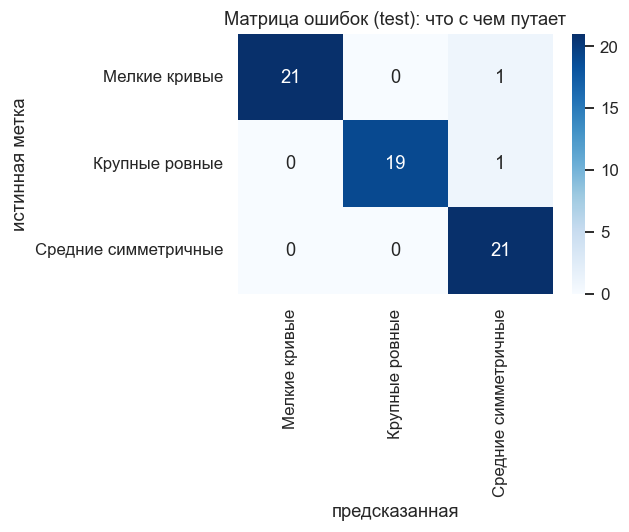

In [26]:
# Матрица ошибок: где классификатор путается
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[cluster_names[i] for i in sorted(cluster_names)],
            yticklabels=[cluster_names[i] for i in sorted(cluster_names)])
plt.title("Матрица ошибок (test): что с чем путает")
plt.ylabel("истинная метка"); plt.xlabel("предсказанная")
plt.tight_layout(); plt.show()

## 5.3 Достаём настоящий сорт и сравниваем с кластерами

Только теперь «открываем» спрятанный столбец `variety` (1=Kama, 2=Rosa, 3=Canadian)
и строим **таблицу соответствия** кластер ↔ настоящий сорт. Это проверка по принципу
«не верь — проверь»: совпали ли наши группы с реальностью и где кластеризация ошиблась.

Таблица соответствия (кластер  vs  настоящий сорт):


variety_name,Canadian,Kama,Rosa
segment,,,
Крупные ровные,0,2,65
Мелкие кривые,66,6,0
Средние симметричные,4,62,5


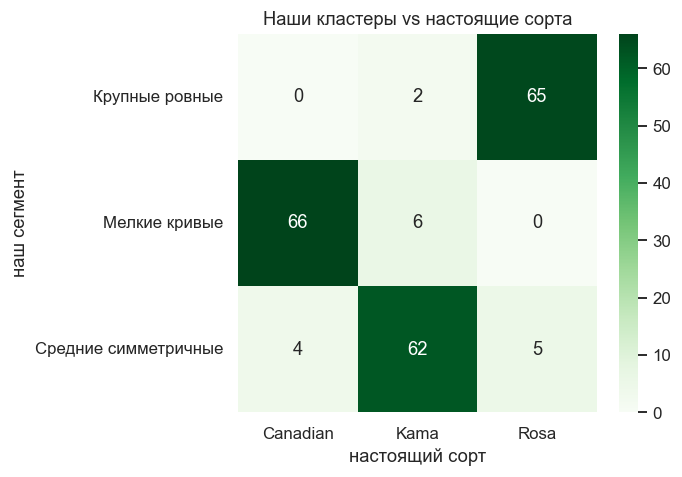

In [27]:
variety_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
df["variety_name"] = df["variety"].map(variety_names)

# Таблица соответствия: строки — наши кластеры, столбцы — настоящие сорта
match = pd.crosstab(df["segment"], df["variety_name"])
print("Таблица соответствия (кластер  vs  настоящий сорт):")
display(match)

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(match, annot=True, fmt="d", cmap="Greens")
plt.title("Наши кластеры vs настоящие сорта")
plt.ylabel("наш сегмент"); plt.xlabel("настоящий сорт")
plt.tight_layout(); plt.show()

In [28]:
# Сопоставляем каждый кластер его доминирующему сорту и считаем совпадение
mapping = match.idxmax(axis=1)               # какой сорт преобладает в каждом кластере
print("Каждый кластер -> преобладающий сорт:")
for seg, var in mapping.items():
    print(f"  {seg:22s} -> {var}")

correct = sum(match.loc[seg, var] for seg, var in mapping.items())
total = len(df)
print(f"\nСовпало с настоящим сортом: {correct} из {total} = {correct/total*100:.1f}%")
print(f"Кластеризация 'ошиблась' на: {total-correct} зёрнах = {(total-correct)/total*100:.1f}%")

Каждый кластер -> преобладающий сорт:
  Крупные ровные         -> Rosa
  Мелкие кривые          -> Canadian
  Средние симметричные   -> Kama

Совпало с настоящим сортом: 193 из 210 = 91.9%
Кластеризация 'ошиблась' на: 17 зёрнах = 8.1%


## 🎯 Итоговый честный вывод

### Метка не случайна — группы реальные и разделимы
Логистическая регрессия на отложенном тесте (зёрна, которых она не видела):

| метрика | значение |
|---|---|
| Accuracy  | **0.968** |
| Precision (macro) | **0.971** |
| Recall (macro)    | **0.968** |
| F1 (macro)        | **0.969** |

Классификатор **уверенно** учит границы между кластерами (~97%). Значит метка `segment`,
которую мы сами сконструировали кластеризацией, — **не разноцветный шум**, а настоящая
структура: группы геометрически разделимы.
Единственное заметное место путаницы — «Средние симметричные» ↔ «Мелкие кривые»: ровно те
две группы, что налезали друг на друга на PCA-картинке (шаг 4). Всё сходится.

### Сравнение со спрятанным сортом — совпало на 92%
Открыли настоящий сорт и сопоставили:

| наш кластер | преобладающий сорт |
|---|---|
| Крупные ровные | **Rosa** |
| Мелкие кривые | **Canadian** |
| Средние симметричные | **Kama** |

**Совпало 193 из 210 = 91.9%. Кластеризация «ошиблась» на 17 зёрнах = 8.1%.**

### Что это значит (принцип «не верь — проверь»)
- Мы **не использовали** сорт при кластеризации, а наши группы почти точно его повторили —
  значит геометрия зерна действительно несёт информацию о сорте.
- Но **~8% зёрен попали не в свой кластер** — и это честный вывод: геометрии **не всегда
  достаточно**, чтобы отличить сорт. Перепутались в основном Kama и Canadian — те самые
  похожие группы, из-за которых спорили локоть и силуэт (шаг 2) и которые налезали на PCA (шаг 4).
- Цифра 8% — не провал, а честная граница метода. Группы осмысленные, но не идеальные.

### Цепочка целиком
EDA → масштабирование → KMeans (k выбран по локтю+силуэту) → имена кластерам →
PCA-визуализация (89% дисперсии) → классификатор подтвердил разделимость (F1≈0.97) →
сверка с реальностью (92% совпадения, 8% честной ошибки). Без учителя нашли структуру,
с учителем доказали, что она реальна.